In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.stats import norm
import numpy as np


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_25832\4140137817.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CheckInHour'] = pd.to_datetime(df['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_25832\4140137817.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CheckOutHour'] = pd.to_datetime(df['CheckOutTime']).dt.hour


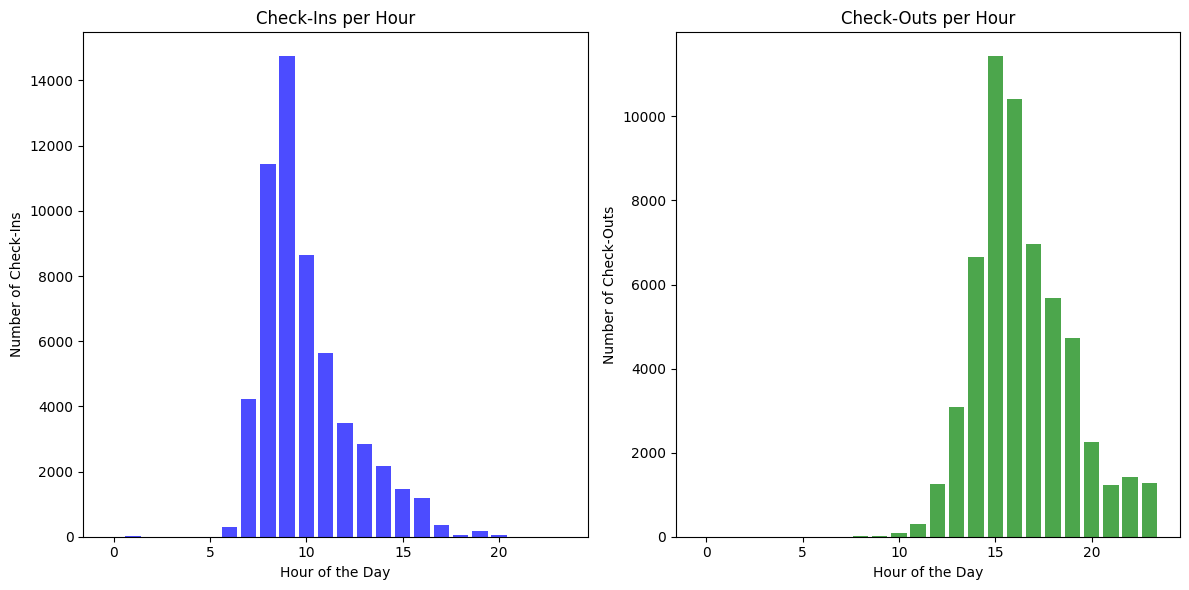

In [2]:

# Load dataset
get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3328_wahetnoor'))
csv_file = '3228_wahetnoor_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

df = pd.read_csv(absolute_path)



# Convert 'CheckInTime' and 'CheckOutTime' from HH:MM format to minutes since midnight
df['CheckInHour'] = pd.to_datetime(df['CheckInTime']).dt.hour 
df['CheckOutHour'] = pd.to_datetime(df['CheckOutTime']).dt.hour 


# Count check-ins per hour
check_in_counts = df['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = df['CheckOutHour'].value_counts().sort_index()


# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

df['CheckInMinutes'] = df['CheckInTime'].apply(time_to_minutes)
df['CheckOutMinutes'] = df['CheckOutTime'].apply(time_to_minutes)

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  MinutesSinceMidnight
0  2024-10-05 00:00:00      6                     0
1  2024-10-05 01:00:00      9                    60
2  2024-10-05 01:30:00      1                    90
3  2024-10-05 02:00:00      3                   120
4  2024-10-05 03:00:00      3                   180
5  2024-10-05 04:00:00      5                   240
6  2024-10-05 04:30:00      1                   270
7  2024-10-05 05:00:00      1                   300
8  2024-10-05 05:30:00      2                   330
9  2024-10-05 06:00:00    293                   360
10 2024-10-05 06:30:00     14                   390
11 2024-10-05 07:00:00    390                   420
12 2024-10-05 07:30:00   3823                   450
13 2024-10-05 08:00:00   4885                   480
14 2024-10-05 08:30:00   6560                   510
15 2024-10-05 09:00:00   9308                   540
16 2024-10-05 09:30:00   5432                   570
17 2024-10-05 10:

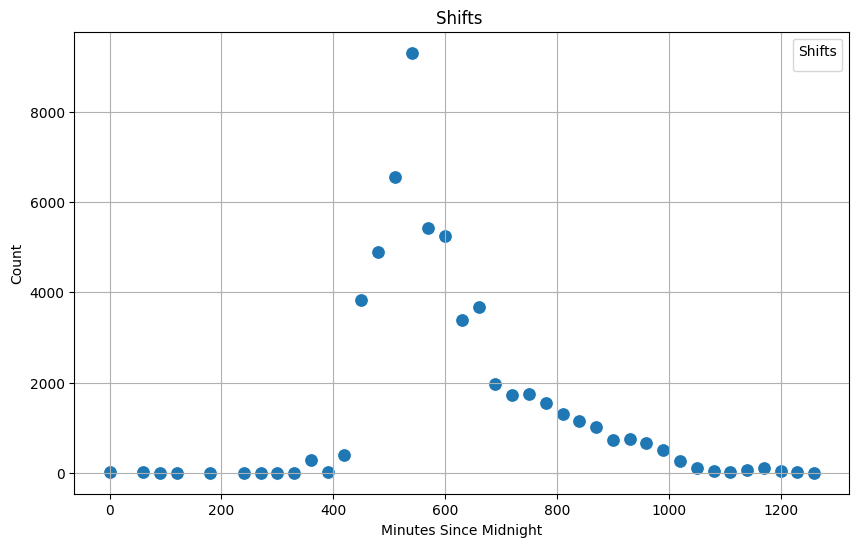

In [3]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
df['CheckInTime'] = pd.to_datetime(df['CheckInTime'], format='%H:%M:%S').dt.time

def round_to_nearest_30_minutes(time):
    # Convert time to minutes, round to nearest 30, then convert back to time
    minute = (time.minute // 30) * 30
    return time.replace(minute=minute, second=0, microsecond=0)

# Apply rounding function
df['RoundedCheckInTime'] = df['CheckInTime'].apply(lambda x: round_to_nearest_30_minutes(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts = df['RoundedCheckInTime'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df = attendance_counts.reset_index()
attendance_df.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)

# Convert TimeInterval to numerical feature (e.g., minutes since midnight)
def time_to_minutes(time_obj):
    # Ensure the time_obj is in proper format (HH:MM)
    if isinstance(time_obj, pd.Timestamp):
        hours, minutes = time_obj.hour, time_obj.minute
    else:
        hours, minutes = map(int, str(time_obj).split(':'))
    return hours * 60 + minutes

attendance_df['MinutesSinceMidnight'] = attendance_df['TimeInterval'].apply(time_to_minutes)

print(attendance_df)

plt.figure(figsize=(10, 6))

#for i in range(optimal_k):
#    cluster_data = attendance_df[attendance_df['Shifts'] == i]
#    plt.scatter(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], label=f'Shifts {i}')
#    plt.plot(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], linestyle='-', marker='o')


sns.scatterplot(x='MinutesSinceMidnight', y='Count', data=attendance_df, s=100)
plt.title('Shifts ')
plt.xlabel('Minutes Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



C:\Users\fzmaj\AppData\Local\Temp\ipykernel_25832\651930444.py:32: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='HoursSinceMidnight', y='Count', data=attendance_df_H, palette='Set1', s=100)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  HoursSinceMidnight
0  2024-10-05 00:00:00      6                   0
1  2024-10-05 01:00:00     10                   1
2  2024-10-05 02:00:00      3                   2
3  2024-10-05 03:00:00      3                   3
4  2024-10-05 04:00:00      6                   4
5  2024-10-05 05:00:00      3                   5
6  2024-10-05 06:00:00    307                   6
7  2024-10-05 07:00:00   4213                   7
8  2024-10-05 08:00:00  11445                   8
9  2024-10-05 09:00:00  14740                   9
10 2024-10-05 10:00:00   8631                  10
11 2024-10-05 11:00:00   5642                  11
12 2024-10-05 12:00:00   3482                  12
13 2024-10-05 13:00:00   2839                  13
14 2024-10-05 14:00:00   2177                  14
15 2024-10-05 15:00:00   1471                  15
16 2024-10-05 16:00:00   1181                  16
17 2024-10-05 17:00:00    373                  17
18 

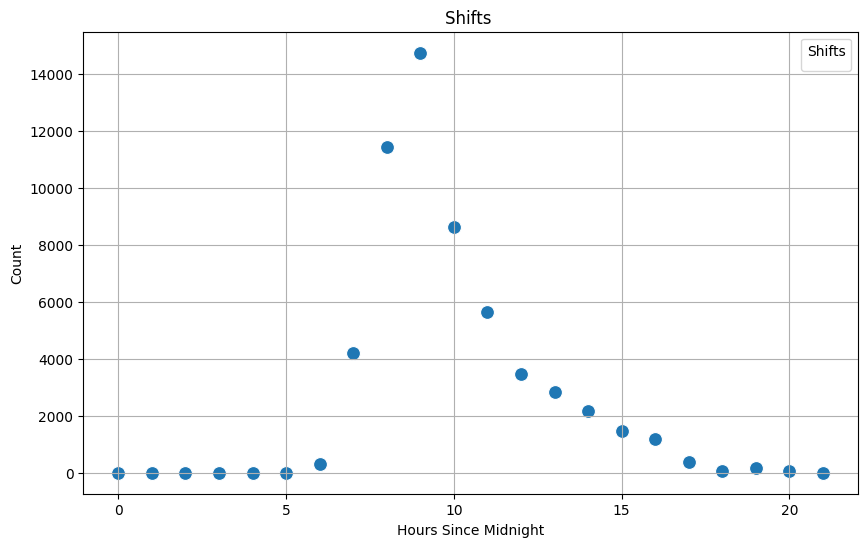

In [4]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
df['CheckInTime'] = pd.to_datetime(df['CheckInTime'], format='%H:%M:%S').dt.time

# Function to round times to the nearest hour
def round_to_nearest_hour(time):
    hour = time.hour
    return time.replace(minute=0, second=0, microsecond=0)

# Apply rounding function
df['RoundedCheckInTime_H'] = df['CheckInTime'].apply(lambda x: round_to_nearest_hour(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts_H = df['RoundedCheckInTime_H'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df_H = attendance_counts_H.reset_index()
attendance_df_H.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)
# Convert TimeInterval to numerical feature (e.g., hours since midnight)
def time_to_hours(time_obj):
    return time_obj.hour

attendance_df_H['HoursSinceMidnight'] = attendance_df_H['TimeInterval'].apply(time_to_hours)

print(attendance_df_H)



plt.figure(figsize=(10, 6))
sns.scatterplot(x='HoursSinceMidnight', y='Count', data=attendance_df_H, palette='Set1', s=100)
plt.title('Shifts ')
plt.xlabel('Hours Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



          TimeInterval  Count  HoursSinceMidnight  Percentage  Shifts
0  2024-10-05 00:00:00      6                   0    0.010562     0.0
1  2024-10-05 01:00:00     10                   1    0.017604     0.0
2  2024-10-05 02:00:00      3                   2    0.005281     0.0
3  2024-10-05 03:00:00      3                   3    0.005281     0.0
4  2024-10-05 04:00:00      6                   4    0.010562     0.0
5  2024-10-05 05:00:00      3                   5    0.005281     0.0
6  2024-10-05 06:00:00    307                   6    0.540436     0.0
7  2024-10-05 07:00:00   4213                   7    7.416470    10.0
8  2024-10-05 08:00:00  11445                   8   20.147520    11.0
9  2024-10-05 09:00:00  14740                   9   25.947963    12.0
10 2024-10-05 10:00:00   8631                  10   15.193818    13.0
11 2024-10-05 11:00:00   5642                  11    9.932049    14.0
12 2024-10-05 12:00:00   3482                  12    6.129634    15.0
13 2024-10-05 13:00:

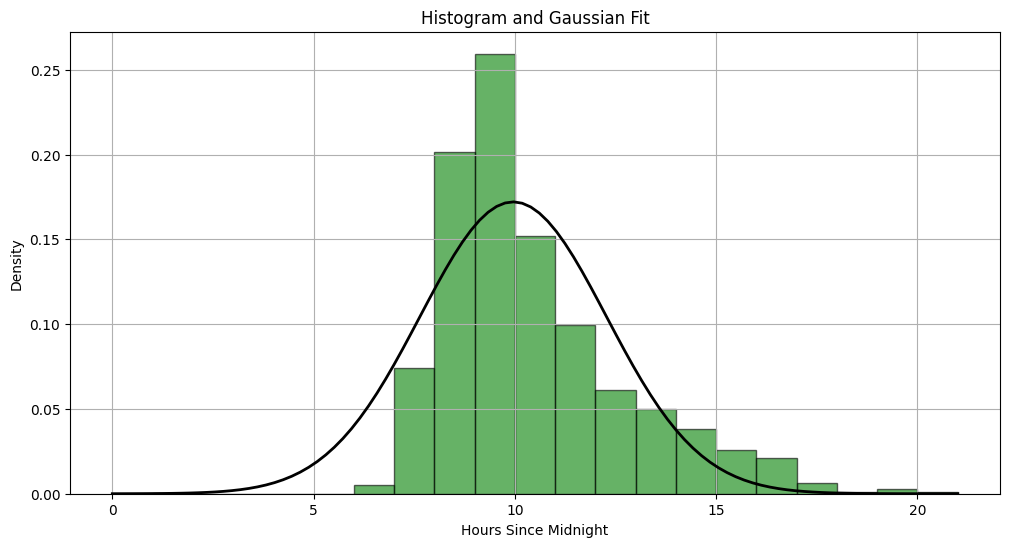

In [5]:

expanded_data = []
for _, row in attendance_df_H.iterrows():
    expanded_data.extend([row['HoursSinceMidnight']] * row['Count'])

expanded_data = np.array(expanded_data)

# Fit Gaussian distribution
mu_in, std_in = norm.fit(expanded_data)

# Create a range of values for plotting the Gaussian distribution
xmin_in, xmax_in = expanded_data.min(), expanded_data.max()
x_in = np.linspace(xmin_in, xmax_in, 100)
p_in = norm.pdf(x_in, mu_in, std_in)


# Calculate the total count
total_count = attendance_df_H['Count'].sum()

# Calculate the percentage of the count for each hour in HoursSinceMidnight
attendance_df_H['Percentage'] = (attendance_df_H['Count'] / total_count) * 100
#print(attendance_df_H)


# Assign shift values based on percentage criteria
attendance_df_H['Shifts'] = attendance_df_H['Percentage'].apply(
    lambda x: 0 if x < 1 else (2 if 1 <= x < 3 else np.nan)
)

# For the remaining rows, assign unique shift numbers
shift_counter = 3
attendance_df_H['Shifts'] = attendance_df_H['Shifts'].fillna(pd.Series(range(shift_counter, shift_counter + len(attendance_df_H))))
print(attendance_df_H.head(24))

# Plot histogram and Gaussian fit
plt.figure(figsize=(12, 6))

# Plot histogram
plt.hist(expanded_data, bins=range(int(xmin_in), int(xmax_in) + 1), density=True, alpha=0.6, color='g', edgecolor='black')

# Plot Gaussian distribution
plt.plot(x_in, p_in, 'k', linewidth=2)

plt.xlabel('Hours Since Midnight')
plt.ylabel('Density')
plt.title('Histogram and Gaussian Fit')
plt.grid(True)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  MinutesSinceMidnight
0  2024-10-05 02:00:00      2                     0
1  2024-10-05 05:30:00      1                    60
2  2024-10-05 06:30:00      1                    90
3  2024-10-05 07:00:00      2                   120
4  2024-10-05 07:30:00      1                   180
5  2024-10-05 08:00:00      7                   240
6  2024-10-05 08:30:00      3                   270
7  2024-10-05 09:00:00      5                   300
8  2024-10-05 09:30:00      7                   330
9  2024-10-05 10:00:00     34                   360
10 2024-10-05 10:30:00     45                   390
11 2024-10-05 11:00:00    126                   420
12 2024-10-05 11:30:00    171                   450
13 2024-10-05 12:00:00    606                   480
14 2024-10-05 12:30:00    640                   510
15 2024-10-05 13:00:00   1656                   540
16 2024-10-05 13:30:00   1435                   570
17 2024-10-05 14:

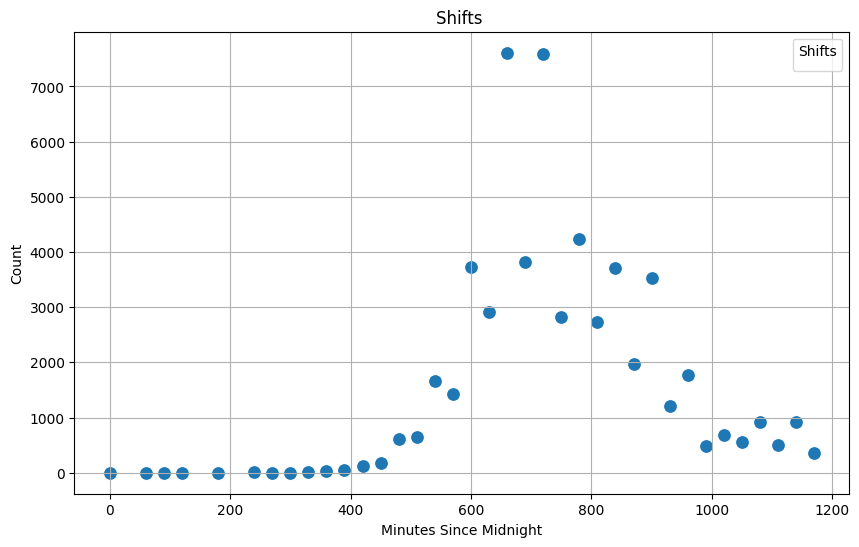

In [6]:
# Convert CheckInTime to datetime format and round to the nearest 30 minutes
df['CheckOutTime'] = pd.to_datetime(df['CheckOutTime'], format='%H:%M:%S').dt.time

def round_to_nearest_30_minutes(time):
    # Convert time to minutes, round to nearest 30, then convert back to time
    minute = (time.minute // 30) * 30
    return time.replace(minute=minute, second=0, microsecond=0)

# Apply rounding function
df['RoundedCheckOutTime'] = df['CheckOutTime'].apply(lambda x: round_to_nearest_30_minutes(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts_out = df['RoundedCheckOutTime'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df_out = attendance_counts_out.reset_index()
attendance_df_out.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)

# Convert TimeInterval to numerical feature (e.g., minutes since midnight)
def time_to_minutes(time_obj):
    # Ensure the time_obj is in proper format (HH:MM)
    if isinstance(time_obj, pd.Timestamp):
        hours, minutes = time_obj.hour, time_obj.minute
    else:
        hours, minutes = map(int, str(time_obj).split(':'))
    return hours * 60 + minutes

attendance_df_out['MinutesSinceMidnight'] = attendance_df['TimeInterval'].apply(time_to_minutes)

print(attendance_df_out)


plt.figure(figsize=(10, 6))

#for i in range(optimal_k):
#    cluster_data = attendance_df[attendance_df['Shifts'] == i]
#    plt.scatter(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], label=f'Shifts {i}')
#    plt.plot(cluster_data['MinutesSinceMidnight'], cluster_data['Count'], linestyle='-', marker='o')


sns.scatterplot(x='MinutesSinceMidnight', y='Count', data=attendance_df_out, s=100)
plt.title('Shifts ')
plt.xlabel('Minutes Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



C:\Users\fzmaj\AppData\Local\Temp\ipykernel_25832\3438571143.py:29: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='HoursSinceMidnight', y='Count', data=attendance_df_out, palette='Set1', s=100)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Attendance Counts for Each 30-Minute Interval:
          TimeInterval  Count  HoursSinceMidnight
0  2024-10-05 02:00:00      2                   2
1  2024-10-05 05:00:00      1                   5
2  2024-10-05 06:00:00      1                   6
3  2024-10-05 07:00:00      3                   7
4  2024-10-05 08:00:00     10                   8
5  2024-10-05 09:00:00     12                   9
6  2024-10-05 10:00:00     79                  10
7  2024-10-05 11:00:00    297                  11
8  2024-10-05 12:00:00   1246                  12
9  2024-10-05 13:00:00   3091                  13
10 2024-10-05 14:00:00   6647                  14
11 2024-10-05 15:00:00  11428                  15
12 2024-10-05 16:00:00  10420                  16
13 2024-10-05 17:00:00   6973                  17
14 2024-10-05 18:00:00   5680                  18
15 2024-10-05 19:00:00   4732                  19
16 2024-10-05 20:00:00   2250                  20
17 2024-10-05 21:00:00   1233                  21
18 

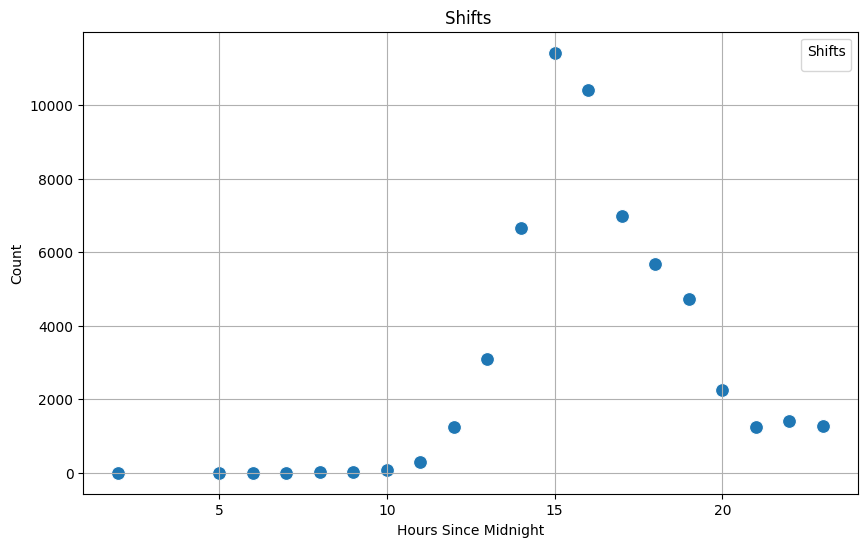

In [7]:

# Function to round times to the nearest hour
def round_to_nearest_hour(time):
    hour = time.hour
    return time.replace(minute=0, second=0, microsecond=0)

# Apply rounding function
df['RoundedCheckOutTime'] = df['CheckOutTime'].apply(lambda x: round_to_nearest_hour(pd.Timestamp.combine(pd.Timestamp.today(), x)))

# Count occurrences for each 30-minute interval
attendance_counts_out = df['RoundedCheckOutTime'].value_counts().sort_index()

# Convert to DataFrame for clustering
attendance_df_out = attendance_counts_out.reset_index()
attendance_df_out.columns = ['TimeInterval', 'Count']

print("Attendance Counts for Each 30-Minute Interval:")
#print(attendance_df)
# Convert TimeInterval to numerical feature (e.g., hours since midnight)
def time_to_hours(time_obj):
    return time_obj.hour

attendance_df_out['HoursSinceMidnight'] = attendance_df_out['TimeInterval'].apply(time_to_hours)

print(attendance_df_out)



plt.figure(figsize=(10, 6))
sns.scatterplot(x='HoursSinceMidnight', y='Count', data=attendance_df_out, palette='Set1', s=100)
plt.title('Shifts ')
plt.xlabel('Hours Since Midnight')
plt.ylabel('Count')
plt.legend(title='Shifts')
plt.grid(True)
plt.show()



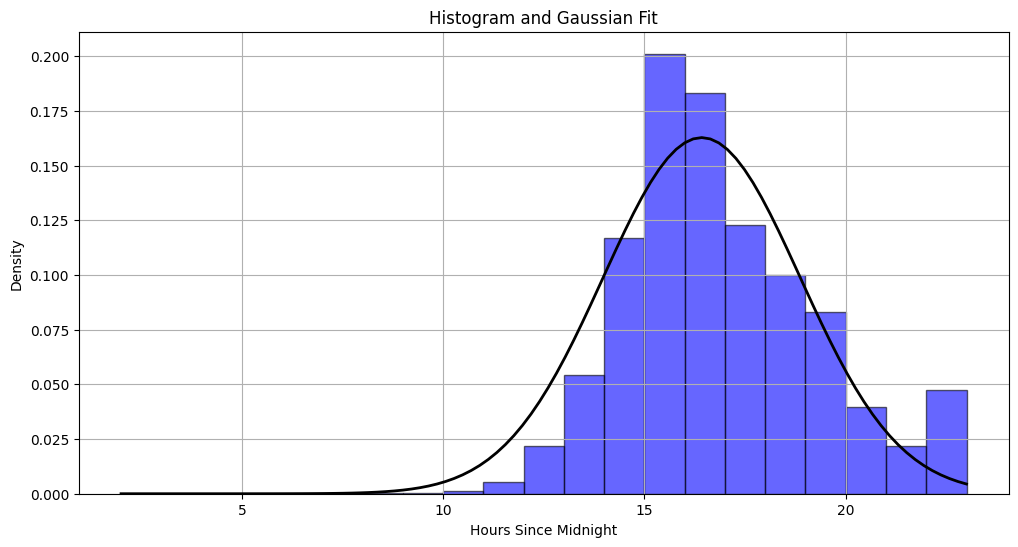

In [8]:

expanded_data_out = []
for _, row in attendance_df_out.iterrows():
    expanded_data_out.extend([row['HoursSinceMidnight']] * row['Count'])

expanded_data_out = np.array(expanded_data_out)

# Fit Gaussian distribution
mu_out, std_out = norm.fit(expanded_data_out)

# Create a range of values for plotting the Gaussian distribution
xmin_out, xmax_out = expanded_data_out.min(), expanded_data_out.max()
x_out = np.linspace(xmin_out, xmax_out, 100)
p_out = norm.pdf(x_out, mu_out, std_out)


# Calculate the total count
total_count = attendance_df_out['Count'].sum()

# Calculate the percentage of the count for each hour in HoursSinceMidnight
attendance_df_out['Percentage'] = (attendance_df_out['Count'] / total_count) * 100
#print(attendance_df_H)


#Plot histogram and Gaussian fit
plt.figure(figsize=(12, 6))

# Plot histogram
plt.hist(expanded_data_out, bins=range(int(xmin_out), int(xmax_out) + 1), density=True, alpha=0.6, color='b', edgecolor='black')

# Plot Gaussian distribution
plt.plot(x_out, p_out, 'k', linewidth=2)

plt.xlabel('Hours Since Midnight')
plt.ylabel('Density')
plt.title('Histogram and Gaussian Fit')
plt.grid(True)
plt.show()

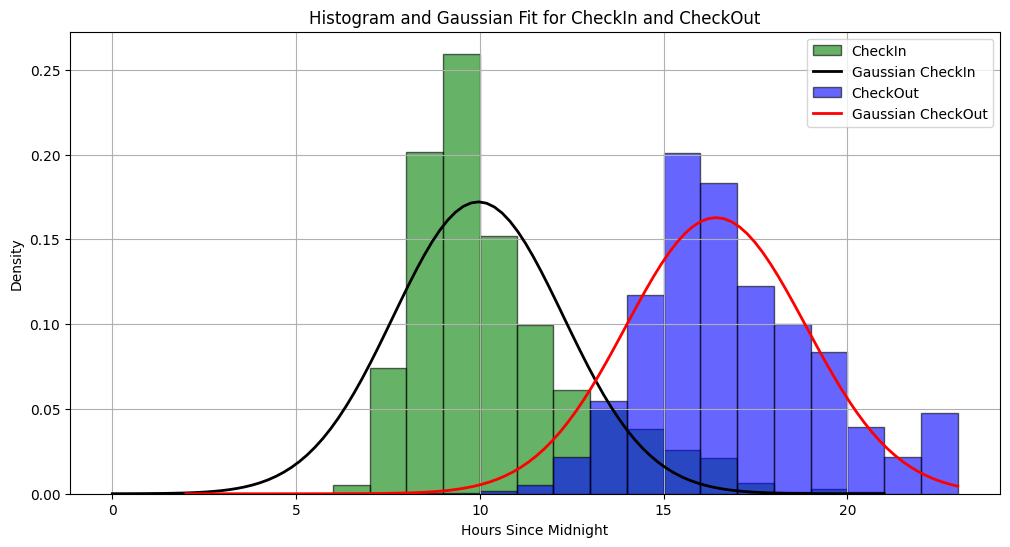

In [9]:

# Plot histogram and Gaussian fit
plt.figure(figsize=(12, 6))

# Plot histogram
plt.hist(expanded_data, bins=range(int(xmin_in), int(xmax_in) + 1), density=True, alpha=0.6, color='g', edgecolor='black', label='CheckIn')

# Plot Gaussian distribution
plt.plot(x_in, p_in, 'k', linewidth=2, label='Gaussian CheckIn')

# Plot histogram for CheckOut
plt.hist(expanded_data_out, bins=range(int(xmin_out), int(xmax_out) + 1), density=True, alpha=0.6, color='b', edgecolor='black', label='CheckOut')

# Plot Gaussian distribution for CheckOut
plt.plot(x_out, p_out, 'r', linewidth=2, label='Gaussian CheckOut')

plt.xlabel('Hours Since Midnight')
plt.ylabel('Density')
plt.title('Histogram and Gaussian Fit for CheckIn and CheckOut')
plt.grid(True)
plt.legend()
plt.show()


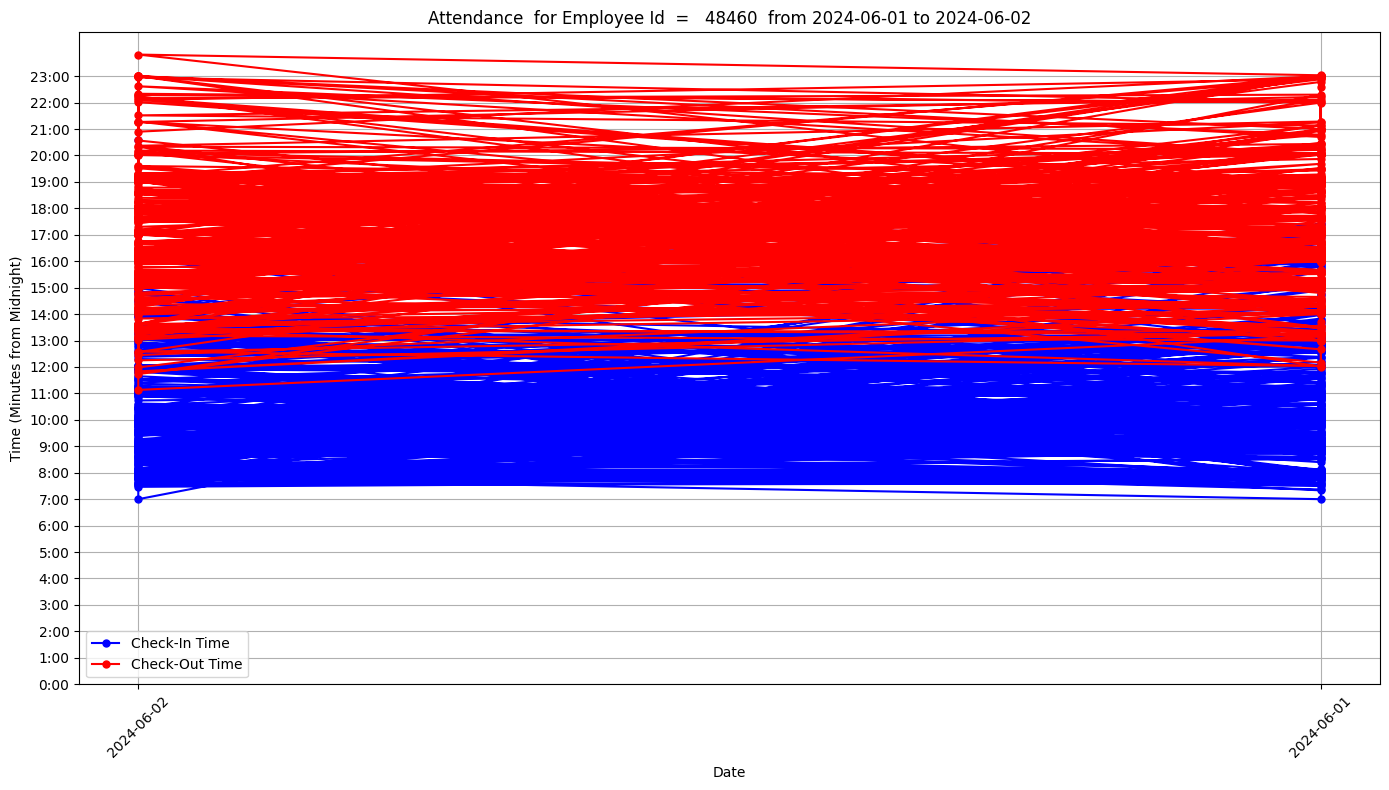

In [10]:

# Define the date range
start_date = '2024-06-01'
end_date = '2024-06-02'

# Filter the DataFrame for the specified date range
#filtered_df = df[(df['Transdate'] >= start_date) & (df['Transdate'] <= end_date) ]
filtered_df = df[
    (df['Transdate'] >= start_date) &
    (df['Transdate'] <= end_date) #&
    #(cluster_df['EmployeeId'] == 49415) #  # 47834
]
# Plot
plt.figure(figsize=(14, 8))

# Plot Check-In times
plt.plot(filtered_df['Transdate'], filtered_df['CheckInMinutes'], 'bo-', label='Check-In Time', markersize=5)

# Plot Check-Out times
plt.plot(filtered_df['Transdate'], filtered_df['CheckOutMinutes'], 'ro-', label='Check-Out Time', markersize=5)

# Customize the plot
plt.title('Attendance  for Employee Id  =   48460  from {} to {}'.format(start_date, end_date))
plt.xlabel('Date')
plt.ylabel('Time (Minutes from Midnight)')
plt.xticks(rotation=45)

# Set y-ticks for every hour in HH:00 format
y_ticks = range(0, 1381, 60)  # Every 60 minutes, up to 23:00 (1380 minutes)
y_labels = [f"{h}:00" for h in range(24)]  # 24 hours
plt.yticks(y_ticks, y_labels)

plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


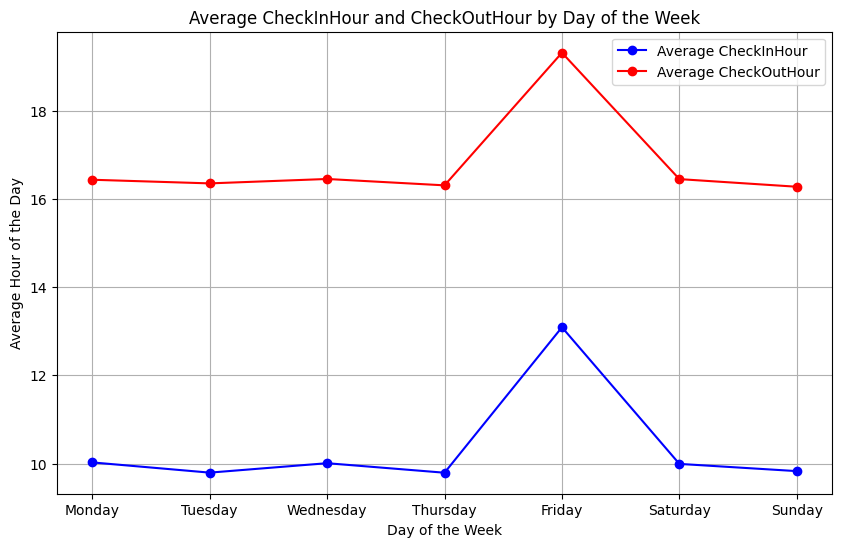

In [11]:
# Check and convert 'TransDate' to datetime if it's not already
df['Transdate'] = pd.to_datetime(df['Transdate'], errors='coerce')

# Extract day of the week again after ensuring the column is datetime
df['DayOfWeek'] = df['Transdate'].dt.day_name()

# Group by DayOfWeek and calculate mean CheckInHour and CheckOutHour
daily_patterns = df.groupby('DayOfWeek')[['CheckInHour', 'CheckOutHour']].mean()

# Sort days in a typical weekly order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_patterns = daily_patterns.reindex(days_order)

# Plot the patterns by day of the week
plt.figure(figsize=(10, 6))

plt.plot(daily_patterns.index, daily_patterns['CheckInHour'], color='b', marker='o', label='Average CheckInHour')
plt.plot(daily_patterns.index, daily_patterns['CheckOutHour'], color='r', marker='o', label='Average CheckOutHour')

plt.xlabel('Day of the Week')
plt.ylabel('Average Hour of the Day')
plt.title('Average CheckInHour and CheckOutHour by Day of the Week')
plt.legend()
plt.grid(True)

plt.show()


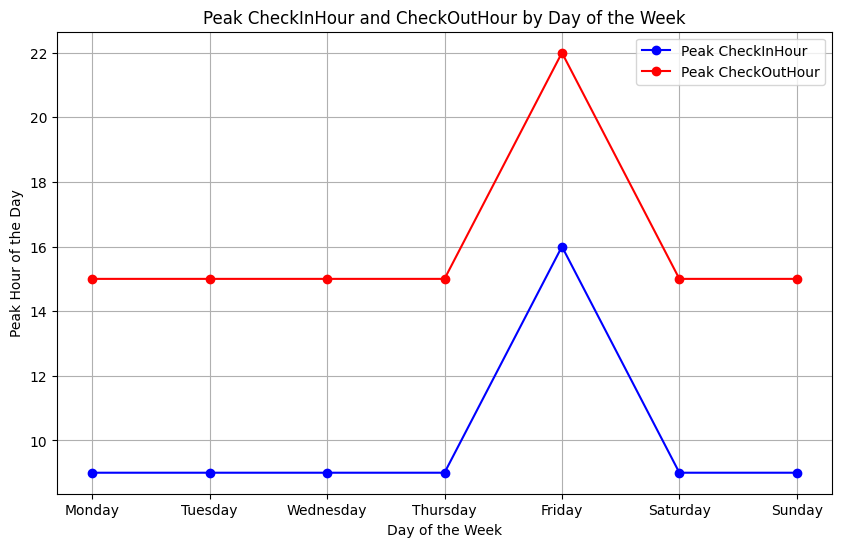

In [12]:
# Find the peak (most frequent) CheckInHour and CheckOutHour for each day of the week
peak_checkin = df.groupby('DayOfWeek')['CheckInHour'].agg(lambda x: x.mode()[0])
peak_checkout = df.groupby('DayOfWeek')['CheckOutHour'].agg(lambda x: x.mode()[0])

# Reindex to ensure the days are ordered correctly
peak_checkin = peak_checkin.reindex(days_order)
peak_checkout = peak_checkout.reindex(days_order)

# Plot peak CheckIn and CheckOut hours by day of the week
plt.figure(figsize=(10, 6))

plt.plot(peak_checkin.index, peak_checkin.values, color='b', marker='o', label='Peak CheckInHour')
plt.plot(peak_checkout.index, peak_checkout.values, color='r', marker='o', label='Peak CheckOutHour')

plt.xlabel('Day of the Week')
plt.ylabel('Peak Hour of the Day')
plt.title('Peak CheckInHour and CheckOutHour by Day of the Week')
plt.legend()
plt.grid(True)

plt.show()


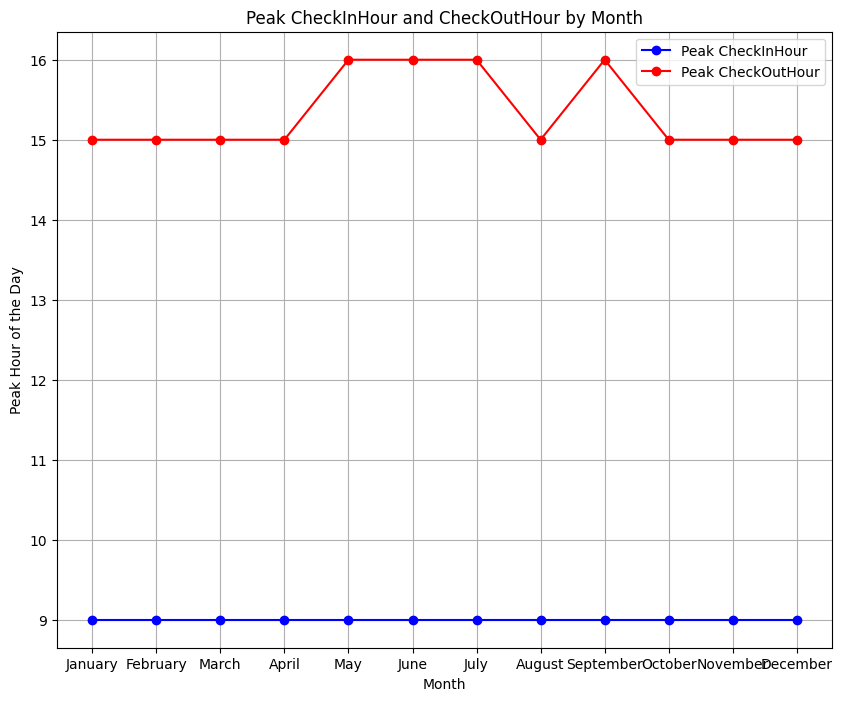

In [13]:
# Extract the month from TransDate
df['Month'] = df['Transdate'].dt.month_name()

# Find the peak (most frequent) CheckInHour and CheckOutHour for each month
peak_checkin_month = df.groupby('Month')['CheckInHour'].agg(lambda x: x.mode()[0])
peak_checkout_month = df.groupby('Month')['CheckOutHour'].agg(lambda x: x.mode()[0])

# Reindex to ensure the months are in calendar order
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
peak_checkin_month = peak_checkin_month.reindex(months_order)
peak_checkout_month = peak_checkout_month.reindex(months_order)

# Plot peak CheckIn and CheckOut hours by month
plt.figure(figsize=(10, 8))

plt.plot(peak_checkin_month.index, peak_checkin_month.values, color='b', marker='o', label='Peak CheckInHour')
plt.plot(peak_checkout_month.index, peak_checkout_month.values, color='r', marker='o', label='Peak CheckOutHour')

plt.xlabel('Month')
plt.ylabel('Peak Hour of the Day')
plt.title('Peak CheckInHour and CheckOutHour by Month')
plt.legend()
plt.grid(True)

plt.show()


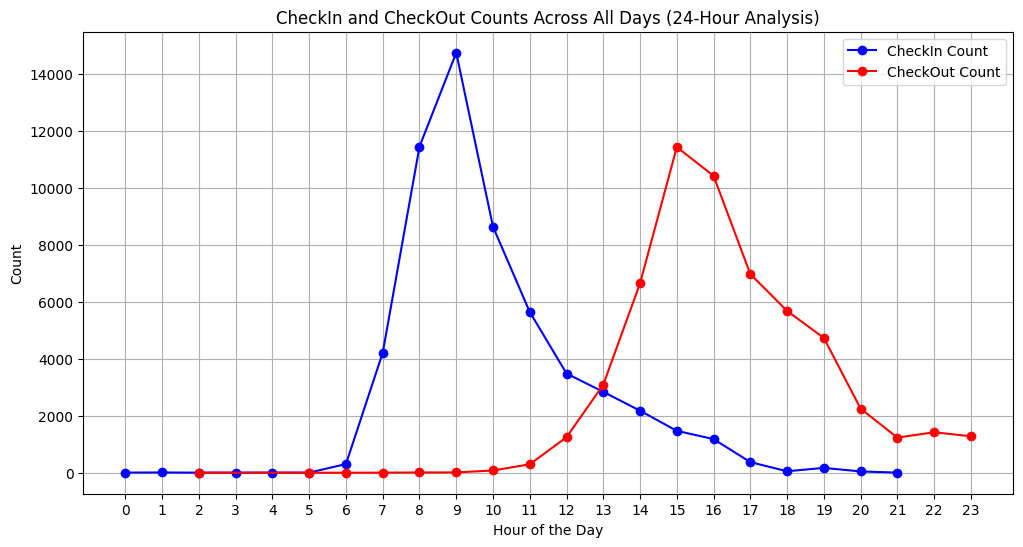

In [14]:
# Group by CheckInHour and CheckOutHour to analyze every hour across all days
checkin_hourly = df.groupby('CheckInHour').size()
checkout_hourly = df.groupby('CheckOutHour').size()

# Plot the CheckIn and CheckOut hourly distribution
plt.figure(figsize=(12, 6))

plt.plot(checkin_hourly.index, checkin_hourly.values, label='CheckIn Count', color='b', marker='o')
plt.plot(checkout_hourly.index, checkout_hourly.values, label='CheckOut Count', color='r', marker='o')

plt.xlabel('Hour of the Day')
plt.ylabel('Count')
plt.title('CheckIn and CheckOut Counts Across All Days (24-Hour Analysis)')
plt.xticks(np.arange(0, 24, 1))  # Ensure all 24 hours are displayed
plt.legend()
plt.grid(True)

plt.show()

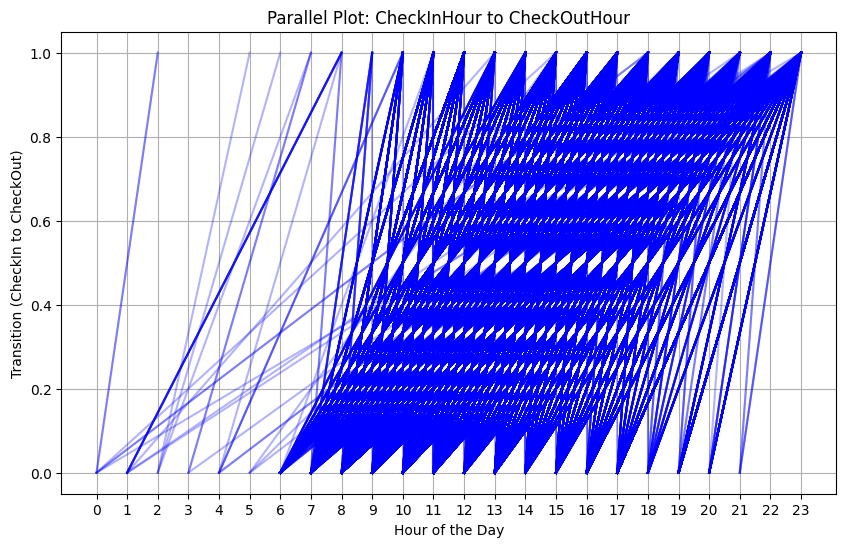

In [15]:
# Parallel line plot connecting CheckInHour to CheckOutHour for each data point

plt.figure(figsize=(10, 6))

# Plot parallel lines connecting each CheckInHour to its corresponding CheckOutHour
for _, row in df.iterrows():
    plt.plot([row['CheckInHour'], row['CheckOutHour']], [0, 1], color='b', alpha=0.3)

plt.xticks(np.arange(0, 24, 1))
plt.xlabel('Hour of the Day')
plt.ylabel('Transition (CheckIn to CheckOut)')
plt.title('Parallel Plot: CheckInHour to CheckOutHour')
plt.grid(True)

plt.show()


Correlation between CheckInHour and CheckOutHour: 0.6935438655474429


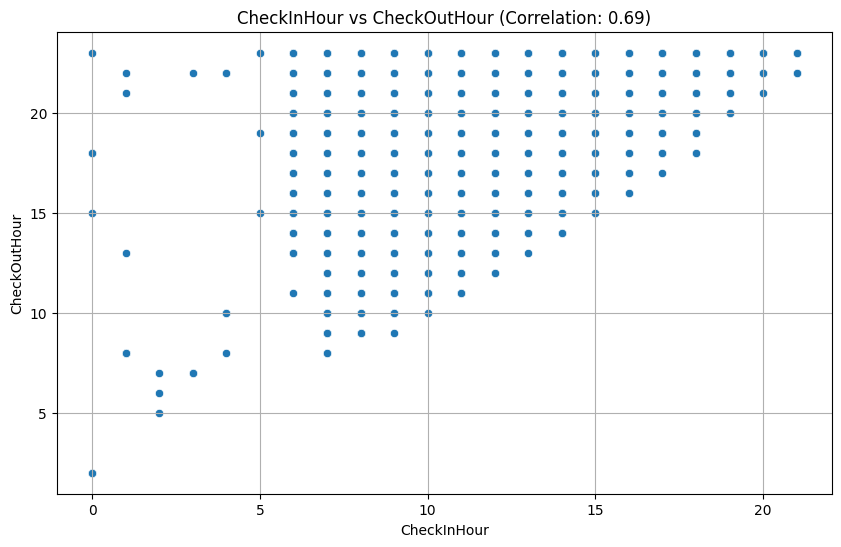

In [16]:
import seaborn as sns
# Calculate Pearson correlation between CheckInHour and CheckOutHour
correlation = df['CheckInHour'].corr(df['CheckOutHour'])

# Display the correlation value
print(f'Correlation between CheckInHour and CheckOutHour: {correlation}')

# Optionally, plot a heatmap or scatter plot to visualize


plt.figure(figsize=(10, 6))

# Scatter plot to visualize relationship
sns.scatterplot(x='CheckInHour', y='CheckOutHour', data=df)

plt.title(f'CheckInHour vs CheckOutHour (Correlation: {correlation:.2f})')
plt.xlabel('CheckInHour')
plt.ylabel('CheckOutHour')
plt.grid(True)
plt.show()


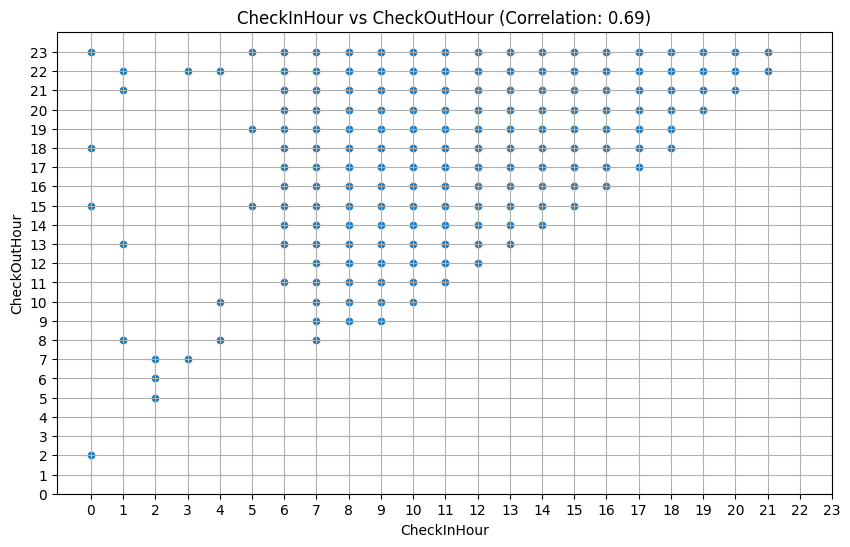

In [17]:

# Calculate Pearson correlation between CheckInHour and CheckOutHour
correlation = df['CheckInHour'].corr(df['CheckOutHour'])

# Scatter plot to visualize relationship with every hour displayed on the scale
plt.figure(figsize=(10, 6))

# Scatter plot to visualize relationship
scatter = sns.scatterplot(x='CheckInHour', y='CheckOutHour', data=df)

plt.title(f'CheckInHour vs CheckOutHour (Correlation: {correlation:.2f})')
plt.xlabel('CheckInHour')
plt.ylabel('CheckOutHour')
plt.grid(True)

# Adjusting the x and y ticks to display every hour
plt.xticks(np.arange(0, 24, 1))
plt.yticks(np.arange(0, 24, 1))

# Function to display the number of EmployeeIds on clicking a point
def on_click(event):
    # Get the coordinates of the click
    if event.inaxes is not None:
        checkin = int(round(event.xdata))
        checkout = int(round(event.ydata))

        # Filter the DataFrame to find matching CheckInHour and CheckOutHour
        matching_data = df[(df['CheckInHour'] == checkin) & (df['CheckOutHour'] == checkout)]
        employee_count = matching_data['EmployeeId'].nunique()

        # Print or display the count of EmployeeIds for the clicked point
        print(f'CheckInHour: {checkin}, CheckOutHour: {checkout}, Employee Count: {employee_count}')

# Connect the click event to the function
plt.gcf().canvas.mpl_connect('button_press_event', on_click)

# Show the plot
plt.show()


In [18]:
# Group by EmployeeId to calculate patterns
employee_patterns = df.groupby('EmployeeId').agg({
    'CheckInHour': ['mean', 'median', lambda x: x.mode()[0]],   # Average, Median, Mode
    'CheckOutHour': ['mean', 'median', lambda x: x.mode()[0]],  # Average, Median, Mode
    'EmployeeId': 'count'  # Total number of records (check-ins)
}).rename(columns={'<lambda_0>': 'mode'}).reset_index()

# Rename columns for clarity
employee_patterns.columns = ['EmployeeId', 'AvgCheckInHour', 'MedianCheckInHour', 'ModeCheckInHour',
                             'AvgCheckOutHour', 'MedianCheckOutHour', 'ModeCheckOutHour', 'TotalCheckIns']

# Display the calculated employee-specific patterns
employee_patterns.head()
df.groupby('EmployeeId').agg({
    'CheckInHour': 'std',   # Standard deviation of check-in times
    'CheckOutHour': 'std'   # Standard deviation of check-out times
})
df['WorkDuration'] = df['CheckOutHour'] - df['CheckInHour']
employee_work_durations = df.groupby('EmployeeId')['WorkDuration'].agg(['mean', 'max', 'min'])


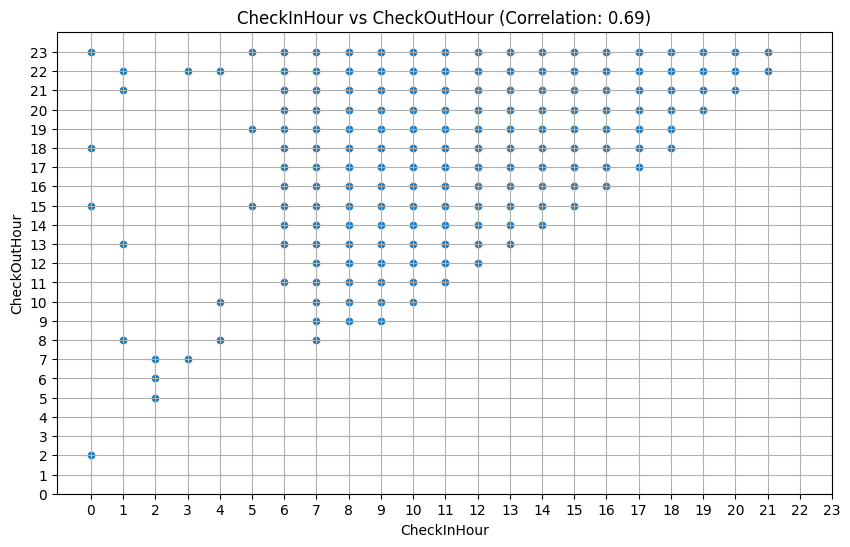

In [19]:
# Calculate Pearson correlation between CheckInHour and CheckOutHour
correlation = df['CheckInHour'].corr(df['CheckOutHour'])

# Scatter plot to visualize relationship with every hour displayed on the scale
plt.figure(figsize=(10, 6))

# Scatter plot to visualize relationship
sns.scatterplot(x='CheckInHour', y='CheckOutHour', data=df)

plt.title(f'CheckInHour vs CheckOutHour (Correlation: {correlation:.2f})')
plt.xlabel('CheckInHour')
plt.ylabel('CheckOutHour')
plt.grid(True)

# Adjusting the x and y ticks to display every hour
plt.xticks(np.arange(0, 24, 1))
plt.yticks(np.arange(0, 24, 1))

plt.show()

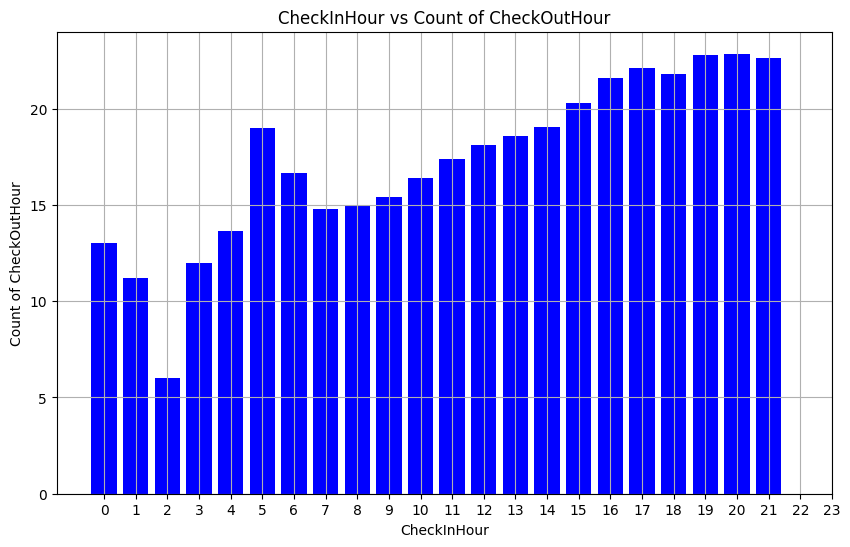

In [20]:
# Group by CheckInHour and get the count of CheckOutHour for each CheckInHour
checkout_counts_by_checkin = df.groupby('CheckInHour')['CheckOutHour'].mean()

# Plot the CheckInHour vs the count of CheckOutHour
plt.figure(figsize=(10, 6))

plt.bar(checkout_counts_by_checkin.index, checkout_counts_by_checkin.values, color='b')

plt.xlabel('CheckInHour')
plt.ylabel('Count of CheckOutHour')
plt.title('CheckInHour vs Count of CheckOutHour')
plt.xticks(np.arange(0, 24, 1))
plt.grid(True)

plt.show()


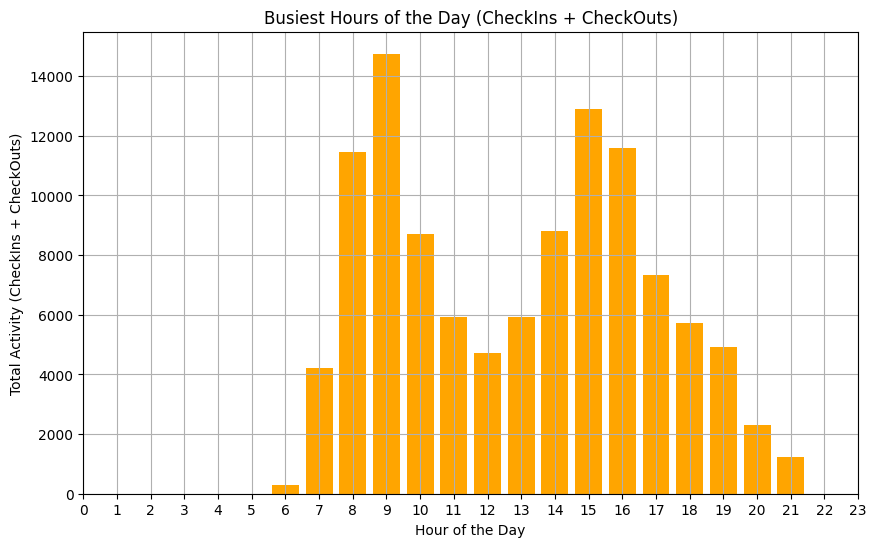

In [21]:
# Summing both CheckInHour and CheckOutHour to identify the busiest hours
busiest_hours = df['CheckInHour'].value_counts() + df['CheckOutHour'].value_counts()

# Sort the values by hour for better visualization
busiest_hours = busiest_hours.sort_index()

# Plot the busiest hours visually
plt.figure(figsize=(10, 6))

plt.bar(busiest_hours.index, busiest_hours.values, color='orange')

plt.xlabel('Hour of the Day')
plt.ylabel('Total Activity (CheckIns + CheckOuts)')
plt.title('Busiest Hours of the Day (CheckIns + CheckOuts)')
plt.xticks(np.arange(0, 24, 1))
plt.grid(True)

plt.show()


In [22]:
# Group by CheckInHour and get the count of CheckOutHour for each CheckInHour
checkout_counts_by_checkin = df.groupby('CheckInHour')['CheckOutHour'].value_counts().unstack(fill_value=0)

# Displaying the result as a DataFrame for easier viewing
checkout_counts_by_checkin


CheckOutHour,2,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
CheckInHour,,,,,,,,,,,,,,,,,,,,
0,2,0,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,0,1
1,0,0,0,0,7,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0
2,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,3,0,0,0,0,0,0,0,0,0,0,0,2,0
5,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1
6,0,0,0,0,0,0,0,1,0,10,18,49,92,51,34,27,13,4,3,5
7,0,0,0,0,2,6,17,58,308,479,712,1694,504,180,93,70,15,29,26,20
8,0,0,0,0,0,5,40,134,447,1252,2525,3838,1861,597,329,151,59,32,36,139


In [23]:
# Filter the dataset where CheckInHour equals 9
checkout_count_for_checkin_9 = df[df['CheckInHour'] == 9]['CheckOutHour'].value_counts()

checkout_count_for_checkin_9


CheckOutHour
16    4171
15    3938
14    2437
17    1549
13     977
18     537
12     395
19     313
23     177
20      82
11      82
21      40
22      23
10      18
9        1
Name: count, dtype: int64